## Project Overview
This project loads a 2D dataset, standardizes feature values, applies the Elbow Method to determine the optimal number of clusters ($K$), and labels data points using the K-Means Clustering algorithm.

## Tech Stack & Requirements

- Python 3.10+
- Pandas for data handling
- Matplotlib for visualization
- Scikit-Learn for feature scaling and clustering

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
df = pd.read_csv("dataset.csv")

In [6]:
df

,x,y
0,0.496714,4.861736
1,0.647689,6.523030
2,-0.234153,4.765863
3,1.579213,5.767435
4,-0.469474,5.542560
...,...,...
145,2.849410,-0.473012
146,3.993856,0.080816
147,2.285222,-0.161692
148,2.497526,0.891180


In [7]:
X = df

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.22272514,  1.27021909],
       [ 0.28070696,  1.94409912],
       [-0.05796505,  1.23132973],
       [ 0.63845951,  1.63760285],
       [-0.14834025,  1.54638567],
       [-0.14601417,  1.13738745],
       [ 0.1248875 ,  0.55020946],
       [-0.63049418,  1.09822018],
       [-0.35701678,  1.45377391],
       [-0.31676556,  0.75342337],
       [ 0.59484516,  1.23472111],
       [ 0.05789598,  0.74837545],
       [-0.17710885,  1.37129816],
       [-0.41007817,  1.4787005 ],
       [-0.19871399,  1.20798265],
       [-0.19912412,  2.07765396],
       [ 0.0267781 ,  0.89725882],
       [ 0.34786067,  0.83108638],
       [ 0.11217593,  0.53139207],
       [-0.47812906,  1.40615794],
       [ 0.31557033,  1.39581709],
       [-0.01245308,  1.20416564],
       [-0.53586569,  1.03430958],
       [-0.14494692,  1.75511041],
       [ 0.16392857,  0.61115218],
       [ 0.1564264 ,  1.17010094],
       [-0.22801065,  1.57442168],
       [ 0.42791781,  1.70406437],
       [-0.29034036,

In [12]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print("WCSS Values For Different K:")

for k,value in zip(range(1,11),wcss):
    print(f"K = {k}, Wcss = {value}")

WCSS Values For Different K:
K = 1, Wcss = 299.9999999999999
K = 2, Wcss = 168.31603619985134
K = 3, Wcss = 44.74628327654689
K = 4, Wcss = 37.038767941721645
K = 5, Wcss = 31.91574777506775
K = 6, Wcss = 27.02290607528485
K = 7, Wcss = 23.614885532854018
K = 8, Wcss = 20.46589692411203
K = 9, Wcss = 17.56479992255255
K = 10, Wcss = 16.11780957464933


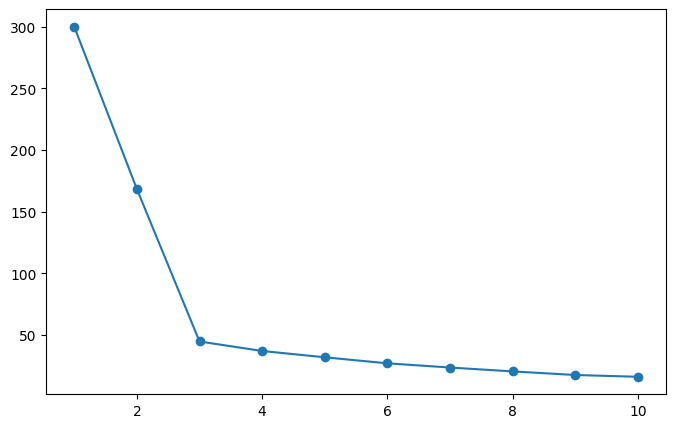

In [16]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.show()

In [21]:
final_k = 4

k_means_final = KMeans(
    n_clusters = final_k,
    random_state = 42,
    init = "k-means++"
)

In [22]:
df["Cluster"] = k_means_final.fit_predict(X_scaled)

In [23]:
df.head(100)

,x,y,Cluster
0,0.496714,4.861736,2
1,0.647689,6.523030,2
2,-0.234153,4.765863,2
3,1.579213,5.767435,2
4,-0.469474,5.542560,2
...,...,...,...
95,-3.195765,0.887503,0
96,-2.377962,-0.953711,3
97,-3.377841,0.109551,0
98,-2.412591,0.781857,3


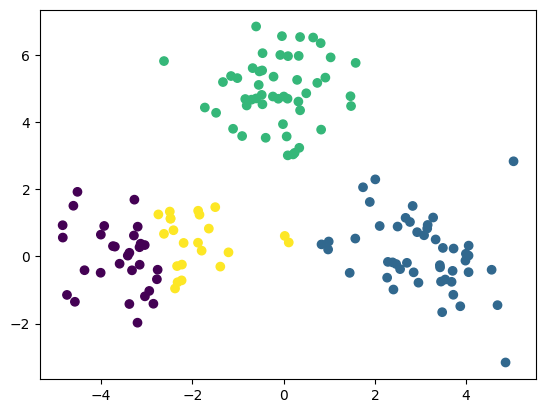

In [25]:
plt.scatter(
    df["x"],df["y"],c=df["Cluster"]
)
plt.show()

## Conclusion
In this analysis, feature scaling via StandardScaler proved essential in ensuring uniform distance computations across dimensions. By plotting the Within-Cluster Sum of Squares (WCSS) across multiple values of $K$, the Elbow Method clearly identified $K = 4$ as the optimal cluster count where inertia reduction levels off. Training the final model with $K=4$ successfully categorized the 2D dataset into four distinct clusters, providing a clean data partitioning pipeline suitable for downstream pattern recognition and spatial segmentation tasks.